In [29]:
#
# notebooks/02_plot_phase_transition.ipynb
#

# =============================================================================
# Cell 1: Setup and Imports
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuration ---
# Path to the results file generated by `03_analyze_checkpoints.py`
#RESULTS_CSV_PATH = "../results/phase_transition_data_llama_02.csv"
#RESULTS_CSV_PATH = "../results/phase_transition_data_gemma-2-2b-it.csv"
RESULTS_CSV_PATH = "../results/phase_transition_llama3b_01_with_disclaimers.csv"
# ---------------------

# Set plotting style for a professional look
sns.set_theme(style="whitegrid")



In [30]:
# =============================================================================
# Cell 2: Load the Results Data
# =============================================================================
try:
    df = pd.read_csv(RESULTS_CSV_PATH)
    print("Results data loaded successfully.")
    print("Data preview:")
    display(df.head(20))
except FileNotFoundError:
    print(f"Error: Results file not found at {RESULTS_CSV_PATH}")
    print("Please run `scripts/03_analyze_checkpoints.py` first.")
    df = None



Results data loaded successfully.
Data preview:


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,disclaimer_rate,n_pairs,n_attacks,n_benign,checkpoint_path
0,0,0.682372,1.156206,16.666667,1.0,30,30,1454,meta-llama/Llama-3.2-3B-Instruct
1,1,0.682071,1.145484,16.666667,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
2,2,0.681707,1.125878,20.000000,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
3,3,0.681229,1.101171,36.666667,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
4,5,0.680166,1.022669,40.000000,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
5,7,0.678830,0.938162,53.333333,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
6,10,0.676884,0.929221,60.000000,0.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
7,12,0.675811,0.965196,60.000000,0.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
8,15,0.671411,1.109445,72.000000,0.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
9,18,0.673963,1.190204,93.333333,6.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...


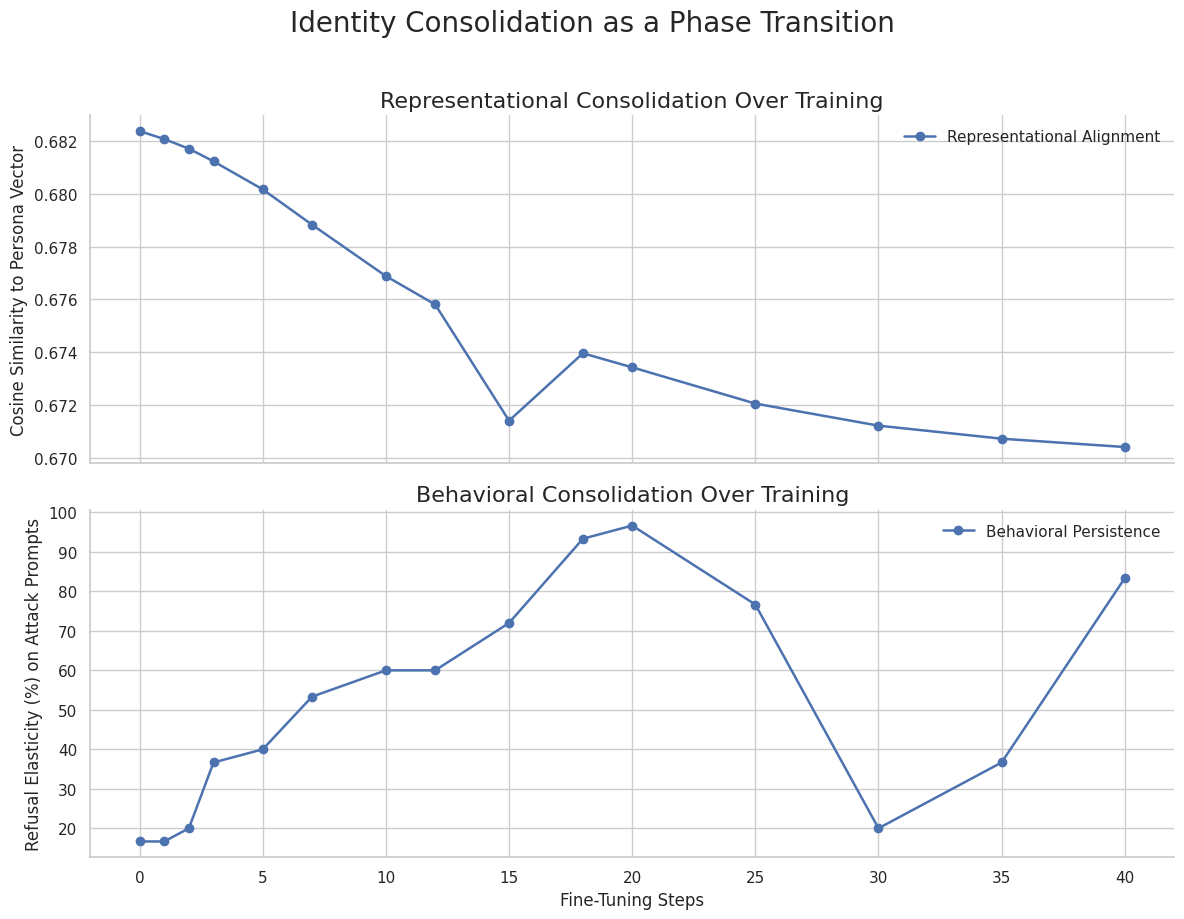

Saved: ../results/fig_phase_transition_llama01.png and ../results/fig_phase_transition_llama01.pdf


In [31]:
# =============================================================================
# Cell 3: Create the Phase Transition Plot (no knee line)
# =============================================================================
# Assumes df is already loaded

df = df.sort_values("checkpoint_step").reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Plot 1: Representational alignment ---
ax1.plot(
    df["checkpoint_step"], df["persona_vector_similarity"],
    marker="o", linewidth=1.8, label="Representational Alignment"
)
ax1.set_title("Representational Consolidation Over Training", fontsize=16)
ax1.set_ylabel("Cosine Similarity to Persona Vector")
ax1.legend(frameon=False)

# --- Plot 2: Behavioral persistence (refusal elasticity) ---
ax2.plot(
    df["checkpoint_step"], df["refusal_elasticity"],
    marker="o", linewidth=1.8, label="Behavioral Persistence"
)
ax2.set_title("Behavioral Consolidation Over Training", fontsize=16)
ax2.set_xlabel("Fine-Tuning Steps")
ax2.set_ylabel("Refusal Elasticity (%) on Attack Prompts")
ax2.legend(frameon=False)

sns.despine()
plt.suptitle("Identity Consolidation as a Phase Transition", fontsize=20, y=1.02)
plt.tight_layout()

# Save figures
out_png = "../results/fig_phase_transition_llama01.png"
out_pdf = "../results/fig_phase_transition_llama01.pdf"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png, "and", out_pdf)


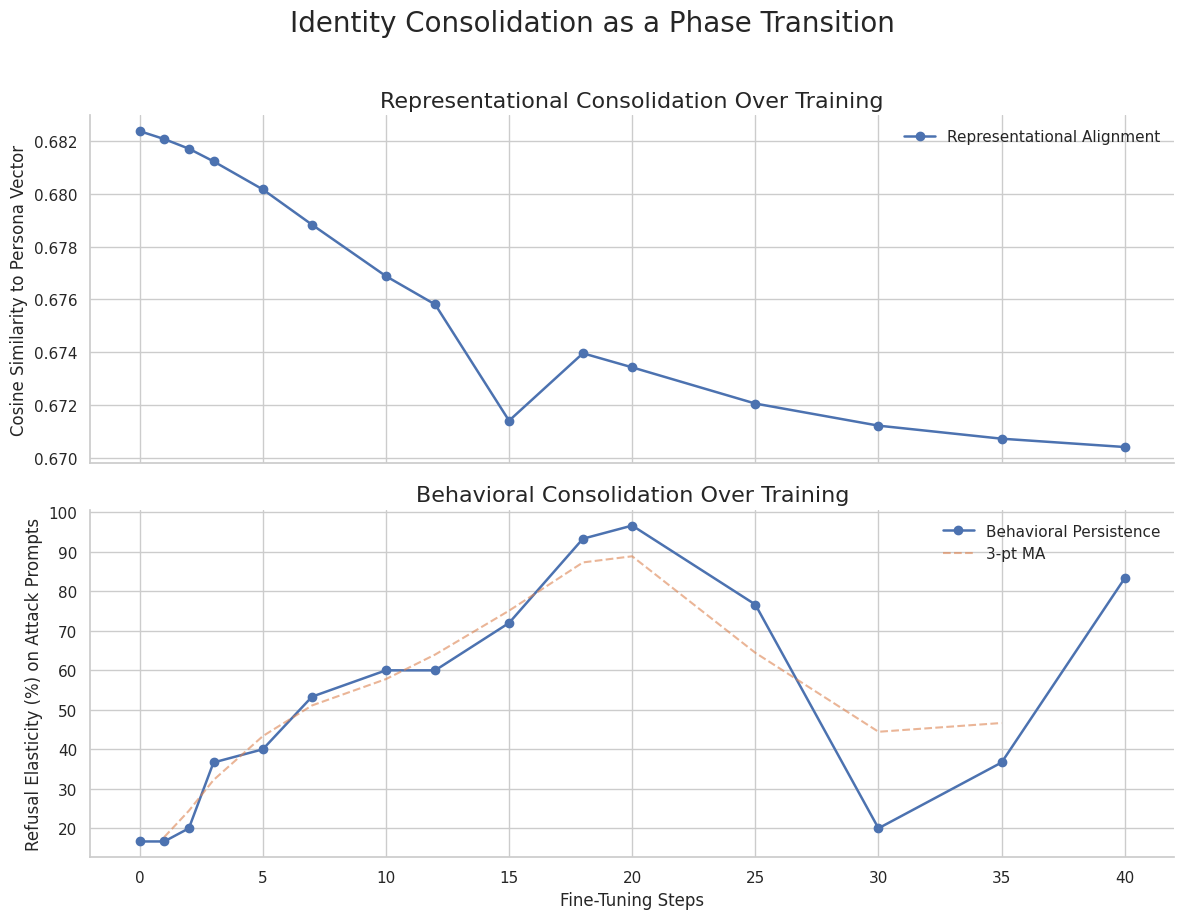

Saved: ../results/fig_phase_transition.png and ../results/fig_phase_transition.pdf


In [36]:
# =============================================================================
# Cell 3: Create the Phase Transition Plot (no knee line)
# =============================================================================
# Assumes df is already loaded

df = df.sort_values("checkpoint_step").reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Plot 1: Representational alignment ---
ax1.plot(
    df["checkpoint_step"], df["persona_vector_similarity"],
    marker="o", linewidth=1.8, label="Representational Alignment"
)
ax1.set_title("Representational Consolidation Over Training", fontsize=16)
ax1.set_ylabel("Cosine Similarity to Persona Vector")
ax1.legend(frameon=False)

# --- Plot 2: Behavioral persistence (refusal elasticity) ---
ax2.plot(
    df["checkpoint_step"], df["refusal_elasticity"],
    marker="o", linewidth=1.8, label="Behavioral Persistence"
)
df["refusal_ma3"] = df["refusal_elasticity"].rolling(window=3, center=True).mean()
ax2.plot(df["checkpoint_step"], df["refusal_ma3"], linestyle="--", alpha=0.6, label="3-pt MA")
ax2.legend(frameon=False)

ax2.set_title("Behavioral Consolidation Over Training", fontsize=16)
ax2.set_xlabel("Fine-Tuning Steps")
ax2.set_ylabel("Refusal Elasticity (%) on Attack Prompts")
ax2.legend(frameon=False)

sns.despine()
plt.suptitle("Identity Consolidation as a Phase Transition", fontsize=20, y=1.02)
plt.tight_layout()

# Save figures
out_png = "../results/fig_phase_transition.png"
out_pdf = "../results/fig_phase_transition.pdf"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png, "and", out_pdf)


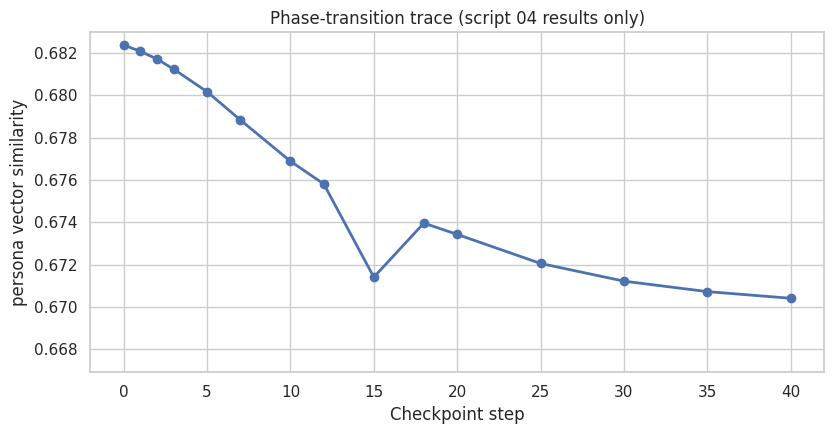

In [39]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

CSV = "../results/phase_transition_llama3b_01_with_disclaimers.csv"  # adjust path if needed
df = pd.read_csv(CSV).sort_values("checkpoint_step")

# Pick a y-axis that's present in the 04 CSV
# - delta_pv_cos: mean cosine((pos-neg), persona_vec) across pairs
# - obs_mean_sim: alternate alignment score from the script
ycol = "persona_vector_similarity" if "persona_vector_similarity" in df.columns else (
        "delta_pv_cos" if "delta_pv_cos" in df.columns else "obs_mean_sim"
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(df["checkpoint_step"], df[ycol], marker="o", lw=2)
ax.set_xlabel("Checkpoint step")
ax.set_ylabel(ycol.replace("_"," "))
ax.set_title("Phase-transition trace (script 04 results only)")

# Optional: tiny “rug” markers for significance so they don’t overlap the curve
have_any = False
ymin, ymax = ax.get_ylim()
span = ymax - ymin
rug_y = ymin - 0.12*span
ax.set_ylim(rug_y - 0.1*span, ymax)

if "perm_p" in df.columns:
    m = df["perm_p"] < 0.05
    ax.scatter(df.loc[m, "checkpoint_step"], [rug_y]*m.sum(),
               s=65, facecolors="none", edgecolors="red", linewidths=1.5,
               label="perm p<0.05")
    have_any = True
    rug_y -= 0.08*span

if "randnull_p" in df.columns:
    m = df["randnull_p"] < 0.05
    ax.scatter(df.loc[m, "checkpoint_step"], [rug_y]*m.sum(),
               marker="*", s=110, color="orange", label="rand-dir p<0.05")
    have_any = True

if have_any:
    ax.legend(loc="best")

plt.tight_layout()
plt.show()
